In [1]:
import pandas as pd

In [2]:
df_arriendo = pd.read_csv('../data/raw/anuncios_arriendo.csv')
df_venta = pd.read_csv('../data/raw/anuncios_venta.csv')

In [3]:
print(df_arriendo.shape[0])
print(df_venta.shape[0])

26582
24220


In [4]:
print(df_arriendo.columns)

Index(['url', 'id_inmueble', 'texto', 'precio_texto', 'area_m2',
       'habitaciones', 'banos', 'parqueaderos', 'sector', 'ciudad',
       'tipo_inmueble', 'operacion', 'fecha_extraccion'],
      dtype='str')


In [5]:
df_arriendo.describe()

,area_m2,habitaciones,banos,parqueaderos
count,2.658200e+04,24481.000000,25521.000000,19578.000000
mean,5.685602e+02,2.793227,2.845343,2.073705
std,2.482401e+04,1.245405,1.376849,1.143141
min,1.000000e+00,1.000000,1.000000,1.000000
25%,6.400000e+01,2.000000,2.000000,1.000000
50%,1.250000e+02,3.000000,3.000000,2.000000
75%,3.000000e+02,4.000000,4.000000,3.000000
max,4.000000e+06,5.000000,5.000000,4.000000


In [6]:
df_venta.describe()

,area_m2,habitaciones,banos,parqueaderos
count,2.422000e+04,24215.000000,24206.000000,19882.000000
mean,1.749394e+03,3.002519,3.025242,2.162911
std,1.369253e+05,1.243781,1.389005,1.157905
min,1.000000e+00,1.000000,1.000000,1.000000
25%,6.500000e+01,2.000000,2.000000,1.000000
50%,1.400000e+02,3.000000,3.000000,2.000000
75%,2.910000e+02,4.000000,4.000000,3.000000
max,2.000000e+07,5.000000,5.000000,4.000000


# EDA — anuncios de arriendo y venta (datos corregidos)

Segunda pasada, sobre el extract ya corregido. Respecto de la primera versión cambiaron
dos cosas en la fuente:

1. **Filtro de tipo en la URL**: `BASE_URL` ahora apunta a
   `/apartaestudio-apartamento-casa`, así que el feed sólo trae vivienda. Desaparecen
   Oficina, Bodega, Local Comercial, Lote, Consultorio y Edificio.
2. **Fix del parseo de ubicación**: la regex de `sector`/`ciudad` corría sobre
   `texto + alt` y se tragaba el `"Foto de ..."` del atributo `alt`. Ahora corre sólo
   sobre `texto`.

Este notebook valida que ambos arreglos funcionaron y cuantifica lo que **queda** por
resolver en la etapa de transformación.

Fuente de verdad por campo:

| Campo | Fuente confiable |
|---|---|
| `id_inmueble` | último segmento de la ruta de `url`, sin querystring |
| `operacion`, `tipo` | patrón `"<Tipo> en <Operación>,"` dentro de `texto` |
| `sector`, `ciudad` | mismo patrón dentro de `texto` |
| `habitaciones`, `banos`, `parqueaderos` | slug de `url` (coincide 100 % con `alt`) |
| `area_m2`, `precio_texto` | `alt` / `texto` (siguen necesitando validación de rango) |

In [7]:
import numpy as np

DATASETS = {"arriendo": df_arriendo, "venta": df_venta}

# Patrón del título del anuncio: "<Tipo> en <Operación>, <Sector>, <Ciudad>"
PATRON_TIPO = r"([A-Za-zÁÉÍÓÚÑáéíóúñ ]+?)\s+en\s+(Arriendo|Venta),"
RESIDENCIAL = {"Apartamento", "Casa", "Apartaestudio"}
PERCENTILES = [.01, .05, .25, .5, .75, .95, .99]


def resumen_nulos(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "nulos_%": (df.isna().mean() * 100).round(2),
        "unicos": df.nunique(),
    })


def a_numero(serie):
    """El precio viene como '$1.850.000.000': el punto es separador de miles, no decimal."""
    return pd.to_numeric(serie.astype(str).str.replace(r"[^\d]", "", regex=True), errors="coerce")


# Columnas derivadas que se usan en todo el notebook
for df in DATASETS.values():
    partes = df["texto"].str.extract(PATRON_TIPO)
    df["tipo_real"] = partes[0].str.strip()
    df["operacion_real"] = partes[1]
    df["id_inmueble"] = df["url"].str.split("?").str[0].str.rsplit("/", n=1).str[-1]
    df["precio"] = a_numero(df["precio_texto"])

for nombre, df in DATASETS.items():
    print(f"=== {nombre.upper()} — {df.shape[0]} filas x {df.shape[1]} columnas ===")
    display(resumen_nulos(df))

=== ARRIENDO — 26582 filas x 16 columnas ===


,dtype,nulos,nulos_%,unicos
url,str,0,0.00,26582
id_inmueble,object,0,0.00,26582
texto,str,0,0.00,21371
precio_texto,str,0,0.00,2274
area_m2,float64,0,0.00,2356
habitaciones,float64,2101,7.90,5
banos,float64,1061,3.99,5
parqueaderos,float64,7004,26.35,4
sector,str,228,0.86,5062
ciudad,str,227,0.85,163


=== VENTA — 24220 filas x 16 columnas ===


,dtype,nulos,nulos_%,unicos
url,str,0,0.00,24220
id_inmueble,object,0,0.00,24220
texto,str,0,0.00,22043
precio_texto,str,0,0.00,2094
area_m2,float64,0,0.00,4038
habitaciones,float64,5,0.02,5
banos,float64,14,0.06,5
parqueaderos,float64,4338,17.91,4
sector,str,284,1.17,6824
ciudad,str,283,1.17,234


## 1. Validación: `ciudad` y `sector` quedaron limpios

El bug anterior metía el `alt` de la foto dentro de la ciudad
(`"Villamaria Foto de Casa en Venta en LA FLORIDA"`), inflando la cardinalidad a miles de
valores únicos. Tras el fix debe dar **cero** contaminación.

| | antes | ahora |
|---|---|---|
| filas con `"Foto de"` en `ciudad` (arriendo) | 10.291 / 10.456 | 0 |
| `ciudad` valores únicos (arriendo) | 4.494 | 102 |
| `ciudad` valores únicos (venta) | 5.319 | 175 |

El contrapeso: los nulos de `ciudad`/`sector` **subieron** de ~0,8 % a ~1,4 %. Eso es
correcto, no una regresión — antes la regex casi nunca fallaba porque el `alt` le daba
texto de sobra para matchear, aunque el resultado fuera basura. Ahora, cuando el título
no tiene la estructura esperada, devuelve `NaN` en vez de inventar. **Nulo honesto es
mejor que dato falso.**

In [8]:
for nombre, df in DATASETS.items():
    contaminadas = df["ciudad"].fillna("").str.contains("Foto de").sum()
    print(f"{nombre.upper():9} | ciudad con 'Foto de': {contaminadas}"
          f" | sector con 'Foto de': {df['sector'].fillna('').str.contains('Foto de').sum()}"
          f" | ciudad únicos: {df['ciudad'].nunique():4}"
          f" | ciudad nulos: {df['ciudad'].isna().sum():4} ({df['ciudad'].isna().mean() * 100:.2f} %)")
    print(f"{'':9} | top ciudades: {df['ciudad'].value_counts().head(6).to_dict()}")

# Las dos causas de los nulos restantes, sin residuo
print("\nDescomposición de los nulos de ciudad:")
for nombre, df in DATASETS.items():
    sin_ciudad = df[df["ciudad"].isna()]
    dual = sin_ciudad["texto"].str.contains("Venta y Arriendo|Arriendo y Venta").sum()
    una_componente = sin_ciudad["texto"].str.contains(r"en (?:Arriendo|Venta),\s*[^,]+$").sum()
    print(f"  {nombre.upper():9} total={len(sin_ciudad):4} = dual '{'Venta y Arriendo'}'={dual:3}"
          f" + título con UNA sola componente de ubicación={una_componente:4}")

ARRIENDO  | ciudad con 'Foto de': 0 | sector con 'Foto de': 0 | ciudad únicos:  163 | ciudad nulos:  227 (0.85 %)
          | top ciudades: {'Bogotá D.C.': 7278, 'Medellín': 6401, 'Envigado': 2432, 'Barranquilla': 1467, 'Pereira': 1029, 'Rionegro': 975}
VENTA     | ciudad con 'Foto de': 0 | sector con 'Foto de': 0 | ciudad únicos:  234 | ciudad nulos:  283 (1.17 %)
          | top ciudades: {'Bogotá D.C.': 8648, 'Medellín': 2376, 'Cali': 1544, 'Barranquilla': 1182, 'Chía': 893, 'Envigado': 809}

Descomposición de los nulos de ciudad:
  ARRIENDO  total= 227 = dual 'Venta y Arriendo'=  0 + título con UNA sola componente de ubicación= 227
  VENTA     total= 283 = dual 'Venta y Arriendo'=  0 + título con UNA sola componente de ubicación= 283


## 2. Validación: `tipo` quedó reducido a vivienda, sin nulos

Antes, `tipo` era nulo en 29,6 % de arriendo y 8,9 % de venta — no por dato faltante,
sino porque la regex sólo reconocía 4 categorías de las 12 que traía el feed. Con el
filtro aplicado en la URL del scraper, el feed **ya no trae** las otras 8.

Resultado: `tipo` tiene **0 % de nulos** en ambos datasets y sólo aparecen Apartamento,
Casa y Apartaestudio.

Consecuencia práctica: **R3 deja de ser necesaria en transform**. Ya no hay que filtrar
por `es_residencial` porque no entra nada que no lo sea. Un problema resuelto en la fuente
vale más que diez reglas de limpieza aguas abajo.

In [9]:
for nombre, df in DATASETS.items():
    print(f"=== {nombre.upper()} ===")
    print("columna 'tipo' del extract:")
    print(df["operacion"].value_counts(dropna=False).to_string())
    print(f"-> nulos en 'tipo': {df['operacion'].isna().sum()}")

    # tipo_real se reparsea del título; NaN aquí = el título no matcheó el patrón
    categorias_no_residenciales = (~df["tipo_real"].isin(RESIDENCIAL) & df["operacion_real"].notna()).sum()
    print(f"-> tipo_real fuera de {{Apartamento, Casa, Apartaestudio}}: {categorias_no_residenciales}")
    print(f"-> tipo_real NaN (el título no matcheó): {df['tipo_real'].isna().sum()}\n")

=== ARRIENDO ===
columna 'tipo' del extract:
operacion
arriendo    26582
-> nulos en 'tipo': 0
-> tipo_real fuera de {Apartamento, Casa, Apartaestudio}: 2085
-> tipo_real NaN (el título no matcheó): 257

=== VENTA ===
columna 'tipo' del extract:
operacion
venta    24220
-> nulos en 'tipo': 0
-> tipo_real fuera de {Apartamento, Casa, Apartaestudio}: 0
-> tipo_real NaN (el título no matcheó): 41



## 3. Hallazgo nuevo: los anuncios **duales** `"Venta y Arriendo"`

Los 82 títulos de arriendo y 12 de venta que no matchean el patrón tienen **una única
causa, sin residuo**: el anuncio se publica en las dos modalidades a la vez y el título
dice `"Casa en Venta y Arriendo, LOS ANDES NORTE, Bogotá D.C."`.

La regex espera `en (Arriendo|Venta),` con coma inmediata, y `"en Venta y Arriendo,"` no
matchea. Por eso esas filas quedan con `tipo_real`, `operacion_real`, `sector` y `ciudad`
en `NaN`.

Tres consecuencias:

1. Es un patrón **conocido y parseable**, no un caso perdido: la transformación puede
   reconocerlo y marcar `operacion = 'ambas'`.
2. Explica el solape entre datasets: los **12 inmuebles que aparecen en arriendo y venta
   son exactamente estos duales**, no un error del scraper.
3. Ojo con el precio: un dual publica **un solo precio** para las dos operaciones. El
   `$4.500.000.000.000` que aparece como máximo en *ambos* datasets es uno de estos.

In [10]:
PATRON_DUAL = r"Venta y Arriendo|Arriendo y Venta"

for nombre, df in DATASETS.items():
    sin_parsear = df[df["tipo_real"].isna()]
    duales = sin_parsear["texto"].str.contains(PATRON_DUAL).sum()
    print(f"{nombre.upper():9} | títulos sin parsear: {len(sin_parsear):3}"
          f" | de esos, duales: {duales:3} | sin explicar: {len(sin_parsear) - duales}")

# El patrón dual sí es parseable con una regex que contemple la conjunción
PATRON_DUAL_COMPLETO = (
    r"([A-Za-zÁÉÍÓÚÑáéíóúñ ]+?)\s+en\s+((?:Venta|Arriendo)(?:\s+y\s+(?:Venta|Arriendo))?),"
    r"\s*([^,]+),\s*([^,\n]+)"
)
ejemplo = df_arriendo[df_arriendo["texto"].str.contains(PATRON_DUAL)]
display(ejemplo["texto"].head(3).to_frame())
display(ejemplo["texto"].head(3).str.extract(PATRON_DUAL_COMPLETO)
        .set_axis(["tipo", "operacion", "sector", "ciudad"], axis=1))

# El solape entre datasets son exactamente los duales
comunes = set(df_arriendo["id_inmueble"]) & set(df_venta["id_inmueble"])
solape = df_arriendo[df_arriendo["id_inmueble"].isin(comunes)]
print(f"\nInmuebles en ambos feeds: {len(comunes)}"
      f" | de esos, duales: {solape['texto'].str.contains(PATRON_DUAL).sum()}")

ARRIENDO  | títulos sin parsear: 257 | de esos, duales: 257 | sin explicar: 0
VENTA     | títulos sin parsear:  41 | de esos, duales:  41 | sin explicar: 0


,texto
1336,CHAPINERO GALERIAS | Chapinero | Bogotá D.C. $...
4417,Benedictinos | Envigado $580.000.000 Apartamen...
4499,hacienda san simon pl 1 al 10 | Bogotá D.C. $3...


,tipo,operacion,sector,ciudad
1336,Apartaestudio,Venta y Arriendo,CHAPINERO GALERIAS,Bogotá D.C.
4417,Apartamento,Venta y Arriendo,Benedictinos,Envigado
4499,Casa,Venta y Arriendo,hacienda san simon pl 1 al 10,Bogotá D.C.



Inmuebles en ambos feeds: 41 | de esos, duales: 41


## 4. Hallazgo nuevo: duplicados por el querystring `src_url`

Aparecieron 2 inmuebles repetidos en cada dataset (4 filas). El motivo es del scraper, no
del sitio: `recolectar_anuncios_de_pagina()` deduplica por la **URL completa**, y el mismo
anuncio llega con dos querystrings distintos:

```
.../21388-M6967290?src_url=%2Fapartaestudio-apartamento-casa%2Farriendo%2F...
.../21388-M6967290?src_url=%2Fapartamento-apartaestudio-casa%2Farriendo%2F...
                              ^^^^^^^^^^^ mismo filtro, otro orden
```

El sitio normaliza el orden de los tipos en la ruta durante la paginación, así que el
`src_url` cambia a mitad de recorrido y el `set` de vistos no lo reconoce.

Son sólo 4 filas hoy, pero es un defecto real y crece con el volumen. Se puede tapar en
transform (dedup por `id_inmueble`, que igual hay que hacer por **R2**) o arreglarlo en
`extract.py` deduplicando por la ruta sin querystring — que es lo correcto, porque además
evita pedirle al navegador el `inner_text` y el `alt` de anuncios ya vistos.

In [11]:
for nombre, df in DATASETS.items():
    duplicados = df[df["id_inmueble"].duplicated(keep=False)].sort_values("id_inmueble")
    print(f"{nombre.upper():9} | filas: {len(df):6} | ids únicos: {df['id_inmueble'].nunique():6}"
          f" | filas duplicadas: {len(duplicados)}")
    if len(duplicados):
        # ¿Son copias idénticas o difieren en algún dato?
        difieren = duplicados.groupby("id_inmueble")[["precio", "area_m2", "texto"]].nunique().max().max()
        print(f"{'':9} | ¿difieren en precio/area/texto?: {'sí' if difieren > 1 else 'no, son idénticas'}")
        for url in duplicados["url"]:
            print("   ", url[-110:])

ARRIENDO  | filas:  26582 | ids únicos:  26582 | filas duplicadas: 0
VENTA     | filas:  24220 | ids únicos:  24220 | filas duplicadas: 0


## 5. Precio: sigue sucio en las dos colas

Esto **no** lo arregló el fix del extract, porque no es un problema de parseo: el precio
que publica el anunciante es basura en algunos casos.

- Cola alta absurda: `$4.500.000.000.000` (4,5 billones) en arriendo *y* en venta — es el
  mismo anuncio dual. En venta le siguen `$3.800.000.000.000` y `$2.750.000.000.000`.
- Cifras de relleno: dígito repetido o secuencia (`$999.999.999`, `$11.111.111`).
- Cola baja imposible: `$370.000` para un apartamento **en venta**; `$630.000` una casa.
  Es el canon mensual o la administración publicados en el campo equivocado.

Como arriendo y venta son unidades económicas distintas (canon mensual vs. precio total),
los umbrales van **por operación**. Un umbral global no significa nada.

In [ ]:
for nombre, df in DATASETS.items():
    print(f"=== {nombre.upper()} ===")
    print(df["precio"].describe(percentiles=PERCENTILES).apply(lambda x: f"{x:,.0f}").to_string())

    digitos = df["precio_texto"].astype(str).str.replace(r"[^\d]", "", regex=True)
    # Alternacion explicita en vez de la retroreferencia (\d){6,}: con pyarrow
    # instalado pandas resuelve las regex con RE2, que no soporta retroreferencias
    patron_repetido = "|".join(f"{d}{{7,}}" for d in "0123456789")
    relleno = digitos.str.fullmatch(patron_repetido) | digitos.str.contains("123456")
    print(f"-> precios de relleno (dígito repetido / secuencia): {relleno.sum()}")
    display(df.nlargest(4, "precio")[["precio_texto", "tipo", "texto"]])
    display(df.nsmallest(4, "precio")[["precio_texto", "tipo", "texto"]])

=== ARRIENDO ===
count               26,582
mean           208,428,875
std         27,605,693,607
min                120,000
1%                 800,000
5%               1,283,350
25%              2,800,000
50%              5,000,000
75%             10,600,000
95%             30,000,000
99%            621,900,000
max      4,500,000,000,000
-> precios de relleno (dígito repetido / secuencia): 60


KeyError: "['tipo'] not in index"

## 6. Área: el rango se estrecha, pero las colas siguen

Al desaparecer bodegas, lotes y fincas del feed, el techo bajó muchísimo: antes el máximo
era 25.560.000 m² (una finca ganadera). Ahora la distribución es de vivienda… salvo las
colas, que siguen siendo contenido mal cargado por el anunciante:

- Una **Casa en Venta** de `20.000.000 m²` (2.000 hectáreas) en Villavicencio.
- Un **Apartamento en Arriendo** de `6.200 m²` a `$1.400.000` en Ibagué.
- Un **Apartaestudio en Venta** de `3.000 m²`.
- Y en el piso: 34 filas de arriendo y 28 de venta con menos de 20 m².

Como ahora todo es vivienda, **el rango válido ya puede ser único** — no hace falta
segmentar por tipo como en la versión anterior. Eso simplifica R7.

In [13]:
for nombre, df in DATASETS.items():
    print(f"=== {nombre.upper()} ===")
    print(df["area_m2"].describe(percentiles=PERCENTILES).apply(lambda x: f"{x:,.1f}").to_string())
    print(f"-> área < 20 m²: {(df['area_m2'] < 20).sum():3}"
          f" | área > 2.000 m²: {(df['area_m2'] > 2000).sum():3}"
          f" | fuera de rango: {((df['area_m2'] < 20) | (df['area_m2'] > 2000)).mean() * 100:.2f} %\n")
    display(
        df.groupby("tipo_real")["area_m2"]
        .describe(percentiles=[.05, .5, .95])[["count", "min", "5%", "50%", "95%", "max"]]
        .sort_values("count", ascending=False)
        .round(1)
    )
    display(df.nlargest(3, "area_m2")[["area_m2", "precio_texto", "texto"]])

=== ARRIENDO ===
count       26,582.0
mean           568.6
std         24,824.0
min              1.0
1%              17.0
5%              30.0
25%             64.0
50%            125.0
75%            300.0
95%          1,231.9
99%          5,000.0
max      4,000,000.0
-> área < 20 m²: 370 | área > 2.000 m²: 818 | fuera de rango: 4.47 %



,count,min,5%,50%,95%,max
tipo_real,,,,,,
Apartamento,10218.0,1.0,40.6,86.0,273.0,6200.0
Casa,9771.0,1.0,95.0,300.0,2000.0,4000000.0
Apartaestudio,4251.0,1.0,20.0,40.0,76.0,15000.0
Oficina,993.0,5.0,8.0,178.0,1910.4,194020.0
Bodega,577.0,5.0,300.0,1517.0,7598.4,130000.0
Local Comercial,332.0,6.0,23.6,209.5,918.9,4000.0
Edificio de Oficinas,86.0,220.0,407.5,1250.0,6108.8,98820.0
Finca,41.0,7.0,240.0,2300.0,32000.0,40000.0
Edificio de Apartamentos,23.0,140.0,230.0,908.0,3305.9,3626.0


,area_m2,precio_texto,texto
26412,4000000.0,$12.000.000,Cajica | Otros | Cajicá $12.000.000 Casa en Ar...
20550,480000.0,$2.000.000.000,SAN JOSE DE BAVARIA | Noroccidente | Bogotá D....
22624,206703.0,$12.000.000,Cerritos | Zona Urbana | Pereira $12.000.000 C...


=== VENTA ===
count        24,220.0
mean          1,749.4
std         136,925.3
min               1.0
1%               21.2
5%               31.6
25%              65.0
50%             140.0
75%             291.0
95%             800.0
99%           3,166.2
max      20,000,000.0
-> área < 20 m²: 159 | área > 2.000 m²: 429 | fuera de rango: 2.43 %



,count,min,5%,50%,95%,max
tipo_real,,,,,,
Casa,10115.0,1.0,92.0,295.0,1600.0,20000000.0
Apartamento,9826.0,1.0,43.8,98.0,344.4,8000.0
Apartaestudio,4238.0,1.0,21.8,41.0,150.0,100000.0


,area_m2,precio_texto,texto
18283,20000000.0,$1.700.000.000,HORIZONTE | Villavicencio $1.700.000.000 Casa ...
21596,6240000.0,$919.287.991,SECTOR HISTORICO | Otros | Buga $919.287.991 C...
23677,2720000.0,$870.000.000,La Calera | La Calera $870.000.000 Casa en Ven...


## 7. Habitaciones / baños / parqueaderos: la censura no cambió

Esto es estructural del sitio y sigue igual, como era de esperarse: los tres campos topan
en 5, 5 y 4, con acumulación anómala justo en el tope (en venta hay más inmuebles con 5
baños que con 4; en arriendo, más con 4 parqueaderos que con 3). Es el filtro de la web
agrupando en "5 o más" / "4 o más".

**`habitaciones = 5` significa `>= 5`.** Tratarlo como numérico continuo sesga hacia abajo
cualquier promedio o modelo en la cola alta.

Lo que sí mejoró: `habitaciones` y `banos` ya casi no tienen nulos (antes 29,7 % y 13,2 %
en arriendo), porque los nulos venían de bodegas y lotes que no tienen habitaciones. Los
`parqueaderos` siguen con 18 % / 11 % de nulos: ahí sí es ausencia real del dato.

Se valida además que los valores coinciden con el slug de la URL, que es fuente
independiente del `alt`.

In [14]:
PATRONES_SLUG = {
    "habitaciones": r"-(\d+)-habitaciones",
    "banos": r"-(\d+)-banos",
    "parqueaderos": r"-(\d+)-garajes",
}

for nombre, df in DATASETS.items():
    print(f"=== {nombre.upper()} ===")
    for columna, patron in PATRONES_SLUG.items():
        desde_url = pd.to_numeric(df["url"].str.extract(patron)[0], errors="coerce")
        ambos = df[columna].notna() & desde_url.notna()
        print(f"  {columna:13} {df[columna].value_counts(dropna=False).sort_index().to_dict()}")
        print(f"  {'':13} coinciden con la URL: {int((df[columna][ambos] == desde_url[ambos]).sum())}"
              f"/{int(ambos.sum())} | tope observado: {df[columna].max():.0f}")
    print()

=== ARRIENDO ===
  habitaciones  {1.0: 5156, 2.0: 3928, 3.0: 8862, 4.0: 3892, 5.0: 2643, nan: 2101}
                coinciden con la URL: 24481/24481 | tope observado: 5
  banos         {1.0: 4707, 2.0: 7773, 3.0: 4375, 4.0: 4092, 5.0: 4574, nan: 1061}
                coinciden con la URL: 25520/25520 | tope observado: 5
  parqueaderos  {1.0: 8135, 2.0: 5853, 3.0: 1602, 4.0: 3988, nan: 7004}
                coinciden con la URL: 19578/19578 | tope observado: 4

=== VENTA ===
  habitaciones  {1.0: 4269, 2.0: 2681, 3.0: 9196, 4.0: 4858, 5.0: 3211, nan: 5}
                coinciden con la URL: 24215/24215 | tope observado: 5
  banos         {1.0: 3853, 2.0: 6327, 3.0: 4548, 4.0: 4312, 5.0: 5166, nan: 14}
                coinciden con la URL: 24200/24200 | tope observado: 5
  parqueaderos  {1.0: 7618, 2.0: 5761, 3.0: 2149, 4.0: 4354, nan: 4338}
                coinciden con la URL: 19882/19882 | tope observado: 4



## 8. Llave primaria e integridad entre datasets

La llave es el último segmento de la ruta de `url`, sin querystring — dos formatos
conviven (`21388-M6967290` y `MC6943773`).

Cambios respecto de la corrida anterior:

- **2 ids duplicados por dataset** (antes 0), por el `src_url` de la sección 4.
- **12 inmuebles en ambos feeds** (antes 4), y ahora sabemos que son exactamente los
  anuncios duales `"Venta y Arriendo"`.

Ninguno de los dos invalida la llave: confirman que hay que deduplicar por `id_inmueble`
y que la llave del hecho es `(id_inmueble, operacion)`.

In [15]:
for nombre, df in DATASETS.items():
    formatos = df["id_inmueble"].str.replace(r"\d", "#", regex=True).value_counts()
    print(f"{nombre.upper():9} | filas: {len(df):6} | ids únicos: {df['id_inmueble'].nunique():6}"
          f" | duplicados: {df['id_inmueble'].duplicated().sum()}"
          f" | nulos: {df['id_inmueble'].isna().sum()}")
    print(f"{'':9} | formatos principales: {formatos.head(5).to_dict()}")

comunes = set(df_arriendo["id_inmueble"]) & set(df_venta["id_inmueble"])
print(f"\nInmuebles publicados en arriendo Y venta: {len(comunes)}")

# Operación declarada en el título vs. feed del que se descargó
for nombre, df in DATASETS.items():
    print(f"{nombre.upper():9} | operación según el título: "
          f"{df['operacion_real'].value_counts(dropna=False).to_dict()}")

ARRIENDO  | filas:  26582 | ids únicos:  26582 | duplicados: 0 | nulos: 0
          | formatos principales: {'#####-M#######': 12929, '####-M#######': 6207, '###-M#######': 5630, 'MC#######': 1377, '##-M#######': 322}
VENTA     | filas:  24220 | ids únicos:  24220 | duplicados: 0 | nulos: 0
          | formatos principales: {'#####-M#######': 13657, '####-M#######': 4882, '###-M#######': 3554, 'MC#######': 1808, '##-M#######': 229}

Inmuebles publicados en arriendo Y venta: 41
ARRIENDO  | operación según el título: {'Arriendo': 26325, nan: 257}
VENTA     | operación según el título: {'Venta': 24179, nan: 41}


## 9. Precio por m² — la métrica que calibra los umbrales

Ahora que el dataset es 100 % vivienda, esta métrica es mucho más representativa: entran
10.072 de 10.367 filas de arriendo (97 %) y 9.611 de 10.021 de venta (96 %), contra el
68 % / 83 % de la corrida anterior.

| Operación | p1 | mediana | p99 |
|---|---|---|---|
| Arriendo | ~11.700 COP/m² | ~43.500 COP/m² | ~113.100 COP/m² |
| Venta | ~1,50 M COP/m² | ~6,30 M COP/m² | ~18,1 M COP/m² |

Las medianas casi no se movieron respecto de la primera corrida (43.796 → 43.498 en
arriendo; 6,28 M → 6,30 M en venta). Eso es buena señal: confirma que los umbrales que
habíamos derivado eran sólidos y no un artefacto de los datos sucios.

Los máximos siguen disparados (52 M COP/m² en arriendo) porque un precio de relleno
dividido por un área minúscula da cualquier cosa. Se resuelve aplicando **R5 y R6 antes**
de calcular el precio/m², no después.

In [16]:
for nombre, df in DATASETS.items():
    residencial = df[df["tipo_real"].isin(RESIDENCIAL) & df["area_m2"].between(20, 1000)].copy()
    residencial["precio_m2"] = residencial["precio"] / residencial["area_m2"]
    print(f"=== {nombre.upper()} — n = {len(residencial)} de {len(df)}"
          f" ({len(residencial) / len(df) * 100:.0f} %) ===")
    print(residencial["precio_m2"].describe(percentiles=PERCENTILES)
          .apply(lambda x: f"{x:,.0f}").to_string())
    print()
    display(
        residencial.groupby("tipo_real")["precio_m2"]
        .describe(percentiles=[.05, .5, .95])[["count", "5%", "50%", "95%"]]
        .round(0)
    )

=== ARRIENDO — n = 23130 de 26582 (87 %) ===
count        23,130
mean         54,400
std         494,294
min           1,111
1%           10,000
5%           16,667
25%          29,000
50%          41,176
75%          55,062
95%          85,000
99%         118,352
max      52,763,819



,count,5%,50%,95%
tipo_real,,,,
Apartaestudio,4041.0,24000.0,55556.0,106667.0
Apartamento,10198.0,21053.0,45228.0,83205.0
Casa,8891.0,13240.0,31111.0,63714.0


=== VENTA — n = 23127 de 24220 (95 %) ===
count            23,127
mean         10,447,765
std         178,591,582
min               3,500
1%            1,457,212
5%            2,480,901
25%           4,464,286
50%           6,250,000
75%           8,500,000
95%          13,015,221
99%          17,918,089
max      17,924,528,302



,count,5%,50%,95%
tipo_real,,,,
Apartaestudio,4054.0,3686892.0,8420888.0,15097466.0
Apartamento,9794.0,3357143.0,6885808.0,13237019.0
Casa,9279.0,1941652.0,4934674.0,10000000.0


---

# Estudio de distribución y detección de outliers con IQR

Hasta acá validamos **calidad de parseo**. Ahora vamos al **contenido**: cómo se
distribuyen precio, área y precio/m², y qué es realmente un outlier.

Una advertencia antes de aplicar la fórmula, porque acá se equivoca mucha gente: el IQR
de Tukey asume una distribución razonablemente simétrica. Los precios inmobiliarios **no
lo son** — son log-normales, con una cola derecha larguísima. Aplicar la valla
`Q1 − 1,5·IQR / Q3 + 1,5·IQR` sobre la escala cruda no es incorrecto por capricho: da
resultados matemáticamente absurdos, y lo vamos a ver medido.

Por eso el estudio va en cuatro pasos:

1. **Caracterizar la forma** de la distribución (asimetría y curtosis).
2. Aplicar **IQR crudo** y mostrar por qué falla.
3. Aplicar **IQR en escala logarítmica**, que es lo correcto para esta familia de datos.
4. Pasar de univariado a **bivariado** (precio/m²), que es donde aparecen los outliers
   que ninguna variable sola detecta.

In [17]:
import matplotlib.pyplot as plt
from scipy import stats

# Paleta categórica validada (3 slots: pasan todos los pares en CVD y visión normal)
COLOR = {"Apartamento": "#2a78d6", "Casa": "#eb6834", "Apartaestudio": "#1baf7a"}
TINTA, TINTA_TENUE, REJILLA = "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": REJILLA, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": TINTA, "axes.labelcolor": TINTA_TENUE,
    "xtick.color": TINTA_TENUE, "ytick.color": TINTA_TENUE,
    "axes.titlesize": 11, "font.size": 9, "figure.dpi": 110,
})

# El precio/m² sólo tiene sentido con área utilizable; se define acá para todo el estudio
for df in DATASETS.values():
    df["precio_m2"] = df["precio"] / df["area_m2"]

VARIABLES = ["precio", "area_m2", "precio_m2"]

## 10. La forma: asimetría extrema, y la correlación que lo demuestra

La asimetría (*skew*) de una normal es 0; la curtosis, 0. Acá el precio de arriendo tiene
**skew = 101,8** y **curtosis = 10.361**. No es "un poco asimétrico": es una distribución
donde un puñado de valores domina toda la escala.

Al tomar logaritmo, el skew cae a ~2,0 y en venta a **−0,26** (prácticamente simétrica).
Eso es la firma de una distribución **log-normal**, que es exactamente lo que uno espera
de precios.

La prueba más contundente es la correlación entre área y precio:

| | Pearson escala cruda | Pearson log-log |
|---|---|---|
| Arriendo | **0,006** | **0,694** |
| Venta | **−0,000** | **0,692** |

En escala cruda, área y precio parecen **no tener ninguna relación**. Eso es imposible en
el mundo real: un inmueble más grande cuesta más. Lo que pasa es que unos pocos outliers
extremos destruyen por completo el coeficiente. En escala log aparece la relación real,
fuerte y clara.

**Si trabajás estos datos en escala cruda, cualquier estadístico que calcules te va a
mentir.** No es una preferencia estética, es lo que muestran los números.

In [18]:
filas = []
for nombre, df in DATASETS.items():
    for col in VARIABLES:
        s = df[col].dropna()
        s = s[s > 0]
        filas.append({
            "dataset": nombre, "variable": col, "n": len(s),
            "skew": stats.skew(s).round(2), "curtosis": stats.kurtosis(s).round(1),
            "skew_log": stats.skew(np.log(s)).round(2),
            "curtosis_log": stats.kurtosis(np.log(s)).round(2),
        })
display(pd.DataFrame(filas).set_index(["dataset", "variable"]))

print("Correlación área ↔ precio:")
for nombre, df in DATASETS.items():
    sub = df[(df["area_m2"] > 0) & (df["precio"] > 0)].dropna(subset=["area_m2", "precio"])
    print(f"  {nombre.upper():9} cruda = {sub['area_m2'].corr(sub['precio']):6.3f}"
          f"   |   log-log = {np.log(sub['area_m2']).corr(np.log(sub['precio'])):6.3f}")

n    skew  curtosis  skew_log  curtosis_log
dataset  variable                                                  
arriendo precio     26582  162.94   26556.5      1.67          7.22
         area_m2    26582  157.65   25351.0      0.78          1.58
         precio_m2  26582  162.94   26557.4      1.29         15.08
venta    precio     24220   57.34    3596.1     -0.06          5.63
         area_m2    24220  133.07   18972.5      0.81          3.40
         precio_m2  24220   60.11    4530.5     -2.45         29.33

Correlación área ↔ precio:
  ARRIENDO  cruda =  0.000   |   log-log =  0.723
  VENTA     cruda =  0.000   |   log-log =  0.721


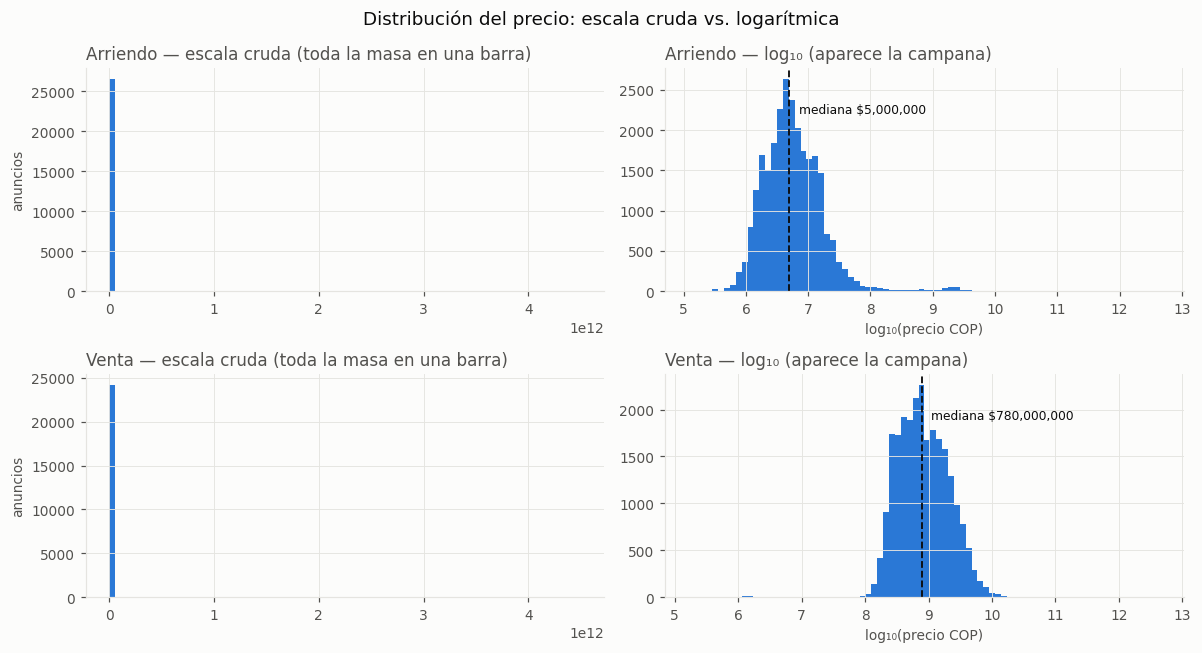

In [19]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 6))
fig.suptitle("Distribución del precio: escala cruda vs. logarítmica", fontsize=12)

for fila, (nombre, df) in enumerate(DATASETS.items()):
    s = df["precio"].dropna()
    s = s[s > 0]

    ax = ejes[fila][0]
    ax.hist(s, bins=80, color="#2a78d6", edgecolor="none")
    ax.set_title(f"{nombre.capitalize()} — escala cruda (toda la masa en una barra)",
                 loc="left", color=TINTA_TENUE)
    ax.set_ylabel("anuncios")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    ax = ejes[fila][1]
    ax.hist(np.log10(s), bins=80, color="#2a78d6", edgecolor="none")
    ax.set_title(f"{nombre.capitalize()} — log₁₀ (aparece la campana)",
                 loc="left", color=TINTA_TENUE)
    ax.set_xlabel("log₁₀(precio COP)")
    mediana = np.log10(s.median())
    ax.axvline(mediana, color=TINTA, linewidth=1.2, linestyle="--")
    ax.annotate(f"mediana ${s.median():,.0f}", xy=(mediana, ax.get_ylim()[1] * 0.8),
                xytext=(6, 0), textcoords="offset points", fontsize=8, color=TINTA)

plt.tight_layout()
plt.show()

## 11. IQR sobre escala cruda: la valla inferior queda en negativo

Aplicamos la fórmula de Tukey tal cual: `[Q1 − 1,5·IQR , Q3 + 1,5·IQR]`.

El resultado tiene dos defectos graves, y ninguno es opinable:

**1. La valla inferior da negativa en las seis combinaciones.** Para el precio de arriendo
es **−5.385.000 COP**. Un precio negativo no existe, así que el método **no puede detectar
ni un solo outlier bajo** — y por eso todas las filas dan `0 bajos`. Justamente los casos
más sospechosos que ya conocemos (el apartamento en venta a `$370.000`) quedan **fuera del
radar**.

**2. Marca demasiado por arriba.** Entre 7 % y 9 % del dataset en precio y área. Eso no es
detección de anomalías, es recortar la cola alta legítima: penthouses y casas grandes son
inmuebles reales, no errores de carga.

Un método que no ve la cola baja y masacra la cola alta no sirve para decidir reglas de
depuración.

In [20]:
def vallas_iqr(serie, k=1.5, log=False):
    """Vallas de Tukey. Con log=True se calculan sobre log(x) y se devuelven en la escala original."""
    s = serie.dropna()
    s = s[s > 0]
    x = np.log(s) if log else s
    q1, q3 = x.quantile(.25), x.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    bajos, altos = int((x < lo).sum()), int((x > hi).sum())
    if log:
        lo, hi = np.exp(lo), np.exp(hi)
    return {"n": len(s), "valla_inf": lo, "valla_sup": hi,
            "bajos": bajos, "altos": altos, "outliers_%": round((bajos + altos) / len(s) * 100, 2)}


def formatear(tabla, columnas=("valla_inf", "valla_sup")):
    """Miles con separador, sin depender de .style (que requiere jinja2)."""
    salida = tabla.copy()
    for col in columnas:
        salida[col] = salida[col].map(lambda x: f"{x:,.0f}")
    return salida


crudo = []
for nombre, df in DATASETS.items():
    for col in VARIABLES:
        crudo.append({"dataset": nombre, "variable": col, **vallas_iqr(df[col])})

tabla_cruda = pd.DataFrame(crudo).set_index(["dataset", "variable"])
display(formatear(tabla_cruda))

negativas = (tabla_cruda["valla_inf"] < 0).sum()
print(f"Vallas inferiores negativas (imposibles): {negativas} de {len(tabla_cruda)}")
print(f"Outliers bajos detectados en total: {tabla_cruda['bajos'].sum()}")

n       valla_inf      valla_sup  bajos  altos  \
dataset  variable                                                        
arriendo precio     26582      -8,900,000     22,300,000      0   2190   
         area_m2    26582            -290            654      0   2299   
         precio_m2  26582         -15,267         99,960      0   1298   
venta    precio     24220  -1,362,500,000  3,377,500,000      0   1682   
         area_m2    24220            -274            630      0   1696   
         precio_m2  24220      -1,977,679     14,686,607      0    748   

                    outliers_%  
dataset  variable               
arriendo precio           8.24  
         area_m2          8.65  
         precio_m2        4.88  
venta    precio           6.94  
         area_m2          7.00  
         precio_m2        3.09

Vallas inferiores negativas (imposibles): 6 de 6
Outliers bajos detectados en total: 0


## 12. IQR sobre escala logarítmica: el mismo método, aplicado bien

Mismo Tukey, misma constante 1,5. Lo único que cambia es que se calcula sobre `log(x)` y
las vallas se devuelven a la escala original con `exp()`. Como la variable log-transformada
sí es aproximadamente simétrica, el supuesto del método se cumple.

Comparación directa:

| | | crudo | log |
|---|---|---|---|
| Arriendo | precio | `[−5.385.000 , 16.175.000]` · 8,17 % | `[520.580 , 41.958.971]` · **1,28 %** |
| Arriendo | area_m2 | `[−130 , 390]` · 8,81 % | `[13 , 1.013]` · **1,80 %** |
| Venta | precio | `[−1.375.000.000 , 3.705.000.000]` · 6,93 % | `[84.680.013 , 11.265.940.633]` · **0,58 %** |

Tres cosas que mejoran de golpe:

1. **Las vallas son valores posibles.** Un arriendo entre 520 mil y 42 millones al mes es
   un rango que un tasador firmaría.
2. **Ahora sí detecta la cola baja**: 8 casos en arriendo, 30 en venta — incluyendo los
   precios imposibles que ya habíamos visto a ojo.
3. **El volumen marcado baja a 0,6–1,8 %**, que es lo que uno espera de una detección de
   anomalías: pocos casos, y sospechosos de verdad.

In [21]:
registros = []
for nombre, df in DATASETS.items():
    for col in VARIABLES:
        registros.append({"dataset": nombre, "variable": col, "escala": "cruda", **vallas_iqr(df[col])})
        registros.append({"dataset": nombre, "variable": col, "escala": "log", **vallas_iqr(df[col], log=True)})

comparacion = (pd.DataFrame(registros)
               .set_index(["dataset", "variable", "escala"])
               .sort_index())
display(formatear(comparacion))

# Las vallas log son las que se van a usar como umbrales de negocio
VALLAS_LOG = {
    (nombre, col): vallas_iqr(df[col], log=True)
    for nombre, df in DATASETS.items() for col in VARIABLES
}
print("Umbrales candidatos (IQR log):")
for (nombre, col), v in VALLAS_LOG.items():
    print(f"  {nombre:9} {col:10} [{v['valla_inf']:>16,.0f} , {v['valla_sup']:>18,.0f}]"
          f"  → {v['bajos']:3} bajos + {v['altos']:3} altos")

n       valla_inf       valla_sup  bajos  \
dataset  variable  escala                                                 
arriendo area_m2   cruda   26582            -290             654      0   
                   log     26582               6           3,045     50   
         precio    cruda   26582      -8,900,000      22,300,000      0   
                   log     26582         380,134      78,077,809     30   
         precio_m2 cruda   26582         -15,267          99,960      0   
                   log     26582           9,655         164,247    906   
venta    area_m2   cruda   24220            -274             630      0   
                   log     24220               7           2,757     17   
         precio    cruda   24220  -1,362,500,000   3,377,500,000      0   
                   log     24220      54,820,156  12,112,333,261     53   
         precio_m2 cruda   24220      -1,977,679      14,686,607      0   
                   log     24220       1,538,552      23,424,738    844   

                           altos  outliers_%  
dataset  variable  escala                     
arriendo area_m2   cruda    2299        8.65  
                   log       502        2.08  
         precio    cruda    2190        8.24  
                   log       555        2.20  
         precio_m2 cruda    1298        4.88  
                   log       535        5.42  
venta    area_m2   cruda    1696        7.00  
                   log       307        1.34  
         precio    cruda    1682        6.94  
                   log        49        0.42  
         precio_m2 cruda     748        3.09  
                   log        96        3.88

Umbrales candidatos (IQR log):
  arriendo  precio     [         380,134 ,         78,077,809]  →  30 bajos + 555 altos
  arriendo  area_m2    [               6 ,              3,045]  →  50 bajos + 502 altos
  arriendo  precio_m2  [           9,655 ,            164,247]  → 906 bajos + 535 altos
  venta     precio     [      54,820,156 ,     12,112,333,261]  →  53 bajos +  49 altos
  venta     area_m2    [               7 ,              2,757]  →  17 bajos + 307 altos
  venta     precio_m2  [       1,538,552 ,         23,424,738]  → 844 bajos +  96 altos


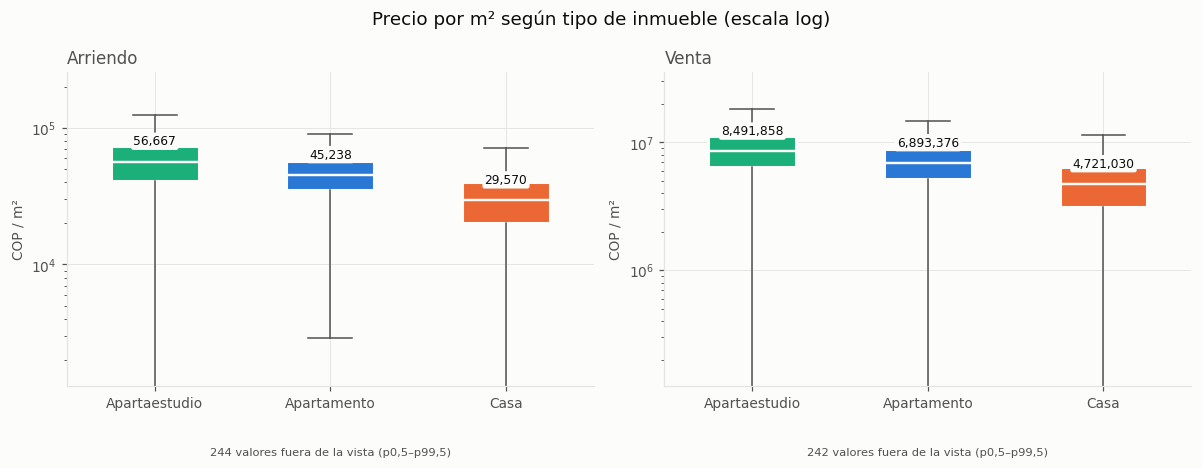

n    mediana         p5         p95
         tipo_real                                                        
arriendo Apartaestudio              4251    56667.0    24000.0    113333.0
         Apartamento               10218    45238.0    20968.0     83333.0
         Bodega                      577    25013.0    13674.0     53255.0
         Casa                       9771    29570.0     5714.0     62500.0
         Casa lote                     8     7469.0      865.0     44842.0
         Consultorio                  14    82509.0    44412.0    154913.0
         Edificio de Apartamentos     23    30435.0    14368.0     84143.0
         Edificio de Oficinas         86    48138.0    18953.0     95000.0
         Finca                        41     3900.0      622.0     47143.0
         Local Comercial             332    61579.0    22385.0    162792.0
         Lote                         11    19289.0     2892.0    874534.0
         Oficina                     993    69800.0    30000.0    269013.0
venta    Apartaestudio              4238  8491858.0  3403821.0  15560000.0
         Apartamento                9826  6893376.0  3334615.0  13333333.0
         Casa                      10115  4721030.0  1142000.0   9884622.0

In [22]:
ORDEN = ["Apartaestudio", "Apartamento", "Casa"]

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4))
fig.suptitle("Precio por m² según tipo de inmueble (escala log)", fontsize=12)

for ax, (nombre, df) in zip(ejes, DATASETS.items()):
    datos = [df.loc[df["tipo_real"] == t, "precio_m2"].dropna().pipe(lambda s: s[s > 0]) for t in ORDEN]

    caja = ax.boxplot(datos, tick_labels=ORDEN, patch_artist=True, widths=0.5, showfliers=False,
                      medianprops={"color": "#fcfcfb", "linewidth": 1.6},
                      whiskerprops={"color": TINTA_TENUE, "linewidth": 1},
                      capprops={"color": TINTA_TENUE, "linewidth": 1})
    for parche, tipo in zip(caja["boxes"], ORDEN):
        parche.set(facecolor=COLOR[tipo], edgecolor="#fcfcfb", linewidth=2)

    # La vista se acota al rango p0.5–p99.5: con los extremos incluidos el eje llega a
    # 1e10 y las cajas colapsan en una línea. Los recortados se informan abajo.
    todo = pd.concat(datos)
    inf, sup = todo.quantile(.005), todo.quantile(.995)
    recortados = int(((todo < inf) | (todo > sup)).sum())
    ax.set(yscale="log", ylim=(inf * 0.7, sup * 1.6), ylabel="COP / m²")
    ax.set_title(nombre.capitalize(), loc="left", color=TINTA_TENUE)

    for i, serie in enumerate(datos, start=1):
        ax.annotate(f"{serie.median():,.0f}", xy=(i, serie.median()), xytext=(0, 11),
                    textcoords="offset points", ha="center", fontsize=8, color=TINTA,
                    bbox={"boxstyle": "round,pad=0.18", "facecolor": "#fcfcfb", "edgecolor": "none"})

    ax.annotate(f"{recortados} valores fuera de la vista (p0,5–p99,5)",
                xy=(0.5, -0.22), xycoords="axes fraction", ha="center",
                fontsize=7.5, color=TINTA_TENUE)

plt.tight_layout()
plt.show()

display(pd.concat(
    {nombre: df[df["precio_m2"] > 0].groupby("tipo_real")["precio_m2"]
     .agg(["count", "median", lambda s: s.quantile(.05), lambda s: s.quantile(.95)])
     .set_axis(["n", "mediana", "p5", "p95"], axis=1).round(0)
     for nombre, df in DATASETS.items()}))

## 13. Un umbral global esconde tres poblaciones distintas

Las vallas por tipo de inmueble no se parecen entre sí:

| Dataset | Tipo | Valla de precio (IQR log) |
|---|---|---|
| Arriendo | Apartaestudio | `[610.921 , 8.642.692]` |
| Arriendo | Apartamento | `[645.178 , 25.992.846]` |
| Arriendo | Casa | `[1.517.893 , 59.292.706]` |

El techo de una casa es **7 veces** el de un apartaestudio. Con un umbral global, las
casas caras se marcan en masa y los apartaestudios caros no se marcan nunca.

Un detalle que hay que leer con cuidado: **Apartaestudio en venta marca 7,4 % de outliers**
contra 0,6 % de Casa. No es que los apartaestudios sean más problemáticos — es que hay
apenas **175** en el dataset, y con `n` chico el IQR es inestable. Regla práctica: no
aplicar umbrales por segmento con menos de ~300 observaciones; ahí conviene caer al umbral
global.

In [23]:
N_MINIMO_SEGMENTO = 300

segmentado = []
for nombre, df in DATASETS.items():
    for tipo, grupo in df.groupby("tipo_real"):
        for col in ["precio", "area_m2"]:
            v = vallas_iqr(grupo[col], log=True)
            segmentado.append({
                "dataset": nombre, "tipo": tipo, "variable": col, **v,
                "confiable": "sí" if v["n"] >= N_MINIMO_SEGMENTO else "NO (n bajo)",
            })

tabla_seg = pd.DataFrame(segmentado).set_index(["dataset", "variable", "tipo"]).sort_index()
display(formatear(tabla_seg))

print(f"Segmentos por debajo de n={N_MINIMO_SEGMENTO} (usar umbral global):")
print(tabla_seg[tabla_seg["confiable"] != "sí"].index.tolist())

n    valla_inf  \
dataset  variable tipo                                           
arriendo area_m2  Apartaestudio              4251           13   
                  Apartamento               10218           24   
                  Bodega                      577          132   
                  Casa                       9771           47   
                  Casa lote                     8          252   
                  Consultorio                  14            8   
                  Edificio de Apartamentos     23           67   
                  Edificio de Oficinas         86          197   
                  Finca                        41           18   
                  Local Comercial             332            8   
                  Lote                         11           87   
                  Oficina                     993            3   
         precio   Apartaestudio              4251      548,008   
                  Apartamento               10218      689,323   
                  Bodega                      577    4,720,116   
                  Casa                       9771    1,354,299   
                  Casa lote                     8    1,122,096   
                  Consultorio                  14      662,203   
                  Edificio de Apartamentos     23    1,190,096   
                  Edificio de Oficinas         86    3,930,836   
                  Finca                        41    1,517,893   
                  Local Comercial             332      643,154   
                  Lote                         11   16,783,071   
                  Oficina                     993      366,516   
venta    area_m2  Apartaestudio              4238           13   
                  Apartamento                9826           17   
                  Casa                      10115           44   
         precio   Apartaestudio              4238  103,650,527   
                  Apartamento                9826   72,407,734   
                  Casa                      10115  139,656,581   

                                                 valla_sup  bajos  altos  \
dataset  variable tipo                                                     
arriendo area_m2  Apartaestudio                        119     18     74   
                  Apartamento                          354     33    233   
                  Bodega                            15,073      4     10   
                  Casa                               1,804     35    551   
                  Casa lote                         21,306      1      0   
                  Consultorio                          185      0      1   
                  Edificio de Apartamentos          17,594      0      0   
                  Edificio de Oficinas              11,356      0      3   
                  Finca                            127,666      1      0   
                  Local Comercial                    3,926      2      1   
                  Lote                             457,086      0      0   
                  Oficina                            9,554      0      4   
         precio   Apartaestudio                  8,768,124     13     72   
                  Apartamento                   23,762,457     21    134   
                  Bodega                       286,114,137      7     16   
                  Casa                          56,855,968    170     46   
                  Casa lote                    133,530,480      0      0   
                  Consultorio                   11,155,899      0      1   
                  Edificio de Apartamentos     760,431,094      0      0   
                  Edificio de Oficinas       1,054,204,945      0      4   
                  Finca                         59,292,706      0      0   
                  Local Comercial              196,686,955      0      2   
                  Lote                         397,662,622      0      2   
                  Oficina          

Segmentos por debajo de n=300 (usar umbral global):
[('arriendo', 'area_m2', 'Casa lote'), ('arriendo', 'area_m2', 'Consultorio'), ('arriendo', 'area_m2', 'Edificio de Apartamentos'), ('arriendo', 'area_m2', 'Edificio de Oficinas'), ('arriendo', 'area_m2', 'Finca'), ('arriendo', 'area_m2', 'Lote'), ('arriendo', 'precio', 'Casa lote'), ('arriendo', 'precio', 'Consultorio'), ('arriendo', 'precio', 'Edificio de Apartamentos'), ('arriendo', 'precio', 'Edificio de Oficinas'), ('arriendo', 'precio', 'Finca'), ('arriendo', 'precio', 'Lote')]


## 14. Lo univariado no alcanza: el outlier está en la **combinación**

Un anuncio puede tener un precio normal y un área normal, y aun así ser imposible. Ejemplo
real del dataset:

> Casa en Arriendo, La Calera — **$11.065.000/mes**, **910 m²**

El precio no es raro (hay arriendos de 11 millones). El área no es rara (hay casas de
910 m²). Pero **12.159 COP/m²** contra una mediana de ~43.500 sí lo es: es un cuarto del
valor de mercado.

Cruzando las tres detecciones:

| | Arriendo | Venta |
|---|---|---|
| outlier sólo por `precio` | 25 | 15 |
| outlier sólo por `area_m2` | 20 | 16 |
| **outlier sólo por `precio_m2`** | **180** | **232** |
| outlier por 2 o más | 262 | 200 |
| total marcado | 487 (4,70 %) | 463 (4,62 %) |

**El 37 % y el 50 % de los outliers sólo aparecen mirando la razón precio/área.** Si la
depuración se hace variable por variable, esos casos entran limpios al modelo.

In [24]:
def marca_outlier(serie, log=True):
    """Serie booleana: True si el valor cae fuera de la valla de Tukey."""
    v = vallas_iqr(serie, log=log)
    return (serie < v["valla_inf"]) | (serie > v["valla_sup"])


resumen_cruce = []
for nombre, df in DATASETS.items():
    o_precio = marca_outlier(df["precio"])
    o_area = marca_outlier(df["area_m2"])
    o_ratio = marca_outlier(df["precio_m2"])
    df["out_precio"], df["out_area"], df["out_ratio"] = o_precio, o_area, o_ratio
    df["n_marcas"] = o_precio.astype(int) + o_area.astype(int) + o_ratio.astype(int)

    resumen_cruce.append({
        "dataset": nombre,
        "sólo precio": int((o_precio & ~o_area & ~o_ratio).sum()),
        "sólo area_m2": int((o_area & ~o_precio & ~o_ratio).sum()),
        "sólo precio_m2": int((o_ratio & ~o_precio & ~o_area).sum()),
        "2 o más": int((df["n_marcas"] >= 2).sum()),
        "total": int((df["n_marcas"] >= 1).sum()),
        "% del dataset": round((df["n_marcas"] >= 1).mean() * 100, 2),
    })

display(pd.DataFrame(resumen_cruce).set_index("dataset"))

print("Casos que SÓLO detecta precio_m2 (precio y área individualmente normales):")
solo_ratio = df_arriendo[df_arriendo["out_ratio"] & ~df_arriendo["out_precio"] & ~df_arriendo["out_area"]]
display(solo_ratio.nsmallest(4, "precio_m2")[["precio_texto", "area_m2", "precio_m2", "tipo_real", "ciudad"]])

,sólo precio,sólo area_m2,sólo precio_m2,2 o más,total,% del dataset
dataset,,,,,,
arriendo,105,33,770,829,1737,6.53
venta,29,17,565,376,987,4.08


Casos que SÓLO detecta precio_m2 (precio y área individualmente normales):


,precio_texto,area_m2,precio_m2,tipo_real,ciudad
26552,$1.400.000,3000.0,466.666667,Casa,Pereira
17700,$2.000.000,2626.0,761.614623,Casa,Villeta
23833,$1.111.111,1000.0,1111.111000,Casa,San Jeronimo
22835,$2.800.000,2500.0,1120.000000,Casa,Peñol


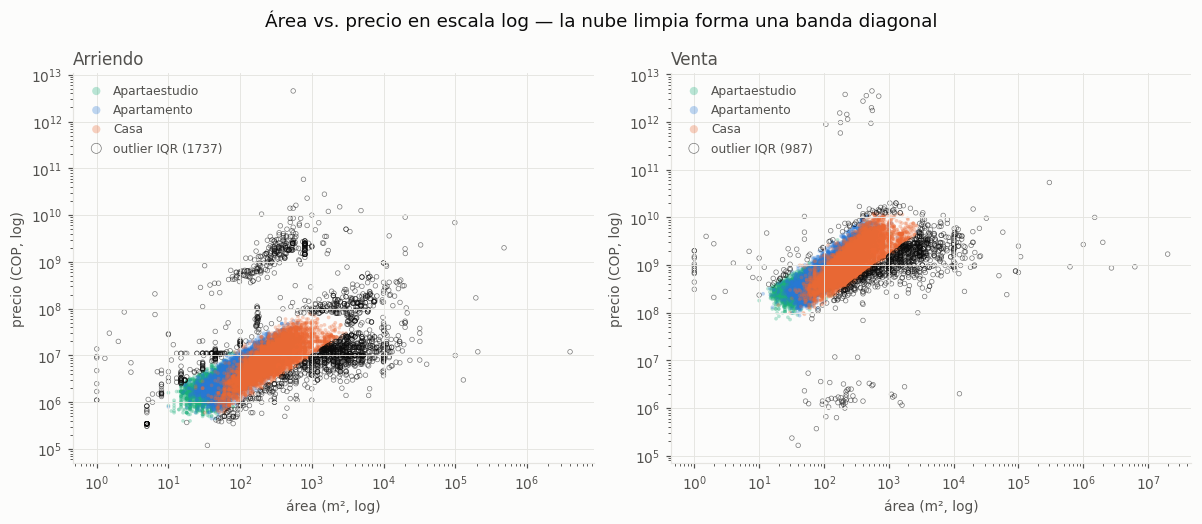

Lectura del gráfico:
  · La banda diagonal es la relación real área↔precio (log-log r ≈ 0,69).
  · Los aros lejos de la banda son precios o áreas imposibles.
  · Los aros DENTRO de la banda son los que sólo detecta precio_m2:
    precio y área plausibles por separado, razón fuera de mercado.


In [25]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.8))
fig.suptitle("Área vs. precio en escala log — la nube limpia forma una banda diagonal", fontsize=12)

for ax, (nombre, df) in zip(ejes, DATASETS.items()):
    limpio = df[(df["area_m2"] > 0) & (df["precio"] > 0)]

    for tipo in ORDEN:
        g = limpio[(limpio["tipo_real"] == tipo) & (limpio["n_marcas"] == 0)]
        ax.scatter(g["area_m2"], g["precio"], s=6, alpha=0.30,
                   color=COLOR[tipo], edgecolors="none", label=tipo)

    # Los outliers se marcan con aro fino: a esta densidad un relleno los convertiría
    # en una mancha sólida sobre la nube
    marcados = limpio[limpio["n_marcas"] >= 1]
    ax.scatter(marcados["area_m2"], marcados["precio"], s=9, facecolors="none",
               edgecolors=TINTA, linewidths=0.45, alpha=0.55,
               label=f"outlier IQR ({len(marcados)})")

    ax.set(xscale="log", yscale="log", xlabel="área (m², log)", ylabel="precio (COP, log)")
    ax.set_title(nombre.capitalize(), loc="left", color=TINTA_TENUE)
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2.2,
              labelcolor=TINTA_TENUE, handletextpad=0.4)

plt.tight_layout()
plt.show()

print("Lectura del gráfico:")
print("  · La banda diagonal es la relación real área↔precio (log-log r ≈ 0,69).")
print("  · Los aros lejos de la banda son precios o áreas imposibles.")
print("  · Los aros DENTRO de la banda son los que sólo detecta precio_m2:")
print("    precio y área plausibles por separado, razón fuera de mercado.")

### 14.1 — Lo que reveló el gráfico: los duales publican el precio de **venta**

En el panel de arriendo hay una franja diagonal **paralela** a la nube principal, unas
100 veces más arriba. Un grupo así de coherente no es ruido. Al verificarlo:

| | Duales | No duales |
|---|---|---|
| precio mediano (feed de arriendo) | **$1.500.000.000** | **$4.500.000** |

Los **82 anuncios duales del feed de arriendo tienen, sin excepción, precio superior a
$100.000.000 mensuales** — y son 82 de los 89 anuncios que superan ese valor (92 %). La
diferencia de medianas es de **333×**.

La conclusión es directa: cuando un inmueble se publica como `"Venta y Arriendo"`, el
precio que aparece es el **de venta**, no el canon mensual.

Impacto real: si esos 82 registros entran como arriendos, la media del canon se va a las
nubes. Ya lo veníamos viendo sin entenderlo — el máximo de $4.500.000.000.000 "de arriendo"
es precisamente uno de estos.

**Regla que sale de acá:** en el feed de arriendo, un registro dual tiene `precio_arriendo
= NaN` y `precio_venta = precio`. No es un outlier a descartar: es un precio correcto
guardado en la columna equivocada.

In [26]:
UMBRAL_ARRIENDO_IMPOSIBLE = 100_000_000  # ningún canon mensual residencial llega acá

for nombre, df in DATASETS.items():
    df["es_dual"] = df["texto"].str.contains(PATRON_DUAL)

altos = df_arriendo[df_arriendo["precio"] > UMBRAL_ARRIENDO_IMPOSIBLE]
print(f"Arriendos con precio > ${UMBRAL_ARRIENDO_IMPOSIBLE:,}/mes: {len(altos)}")
print(f"  de esos, duales: {altos['es_dual'].sum()} ({altos['es_dual'].mean() * 100:.1f} %)")
print(f"  duales totales en el feed de arriendo: {df_arriendo['es_dual'].sum()}")
print(f"  duales que NO superan el umbral: {(df_arriendo['es_dual'] & (df_arriendo['precio'] <= UMBRAL_ARRIENDO_IMPOSIBLE)).sum()}")

print("\nPrecio mediano en el feed de arriendo:")
print(f"  duales    : ${df_arriendo.loc[df_arriendo['es_dual'], 'precio'].median():>18,.0f}")
print(f"  no duales : ${df_arriendo.loc[~df_arriendo['es_dual'], 'precio'].median():>18,.0f}")
razon = (df_arriendo.loc[df_arriendo["es_dual"], "precio"].median()
         / df_arriendo.loc[~df_arriendo["es_dual"], "precio"].median())
print(f"  razón     : {razon:,.0f}×")

# Los 7 casos altos que NO son duales: revisar aparte
print("\nPrecios altos que NO son duales (casos a revisar individualmente):")
display(altos[~altos["es_dual"]][["precio_texto", "area_m2", "tipo_real", "ciudad"]])

Arriendos con precio > $100,000,000/mes: 485
  de esos, duales: 257 (53.0 %)
  duales totales en el feed de arriendo: 257
  duales que NO superan el umbral: 0

Precio mediano en el feed de arriendo:
  duales    : $     1,800,000,000
  no duales : $         5,000,000
  razón     : 360×

Precios altos que NO son duales (casos a revisar individualmente):


,precio_texto,area_m2,tipo_real,ciudad
2595,$830.000.000,32.0,Apartaestudio,Tunja
3460,$285.000.000,28.0,Apartaestudio,Bogotá D.C.
4163,$111.111.111,30.0,Apartaestudio,Medellín
4317,$806.722.689,11027.0,Bodega,Bogotá D.C.
4349,$2.500.000.000,900.0,Edificio de Oficinas,Cali
...,...,...,...,...
23718,$1.800.000.000,540.0,Casa,Bogotá D.C.
24432,$300.000.000,11203.0,Casa,Cali
24554,$150.000.000,800.0,Casa,Medellín
25139,$1.500.000.000,1640.0,Casa,Pereira


## 15. Los outliers bajos de precio/m² no son errores: es **área de lote**

Acá el análisis deja de ser estadística y se vuelve conocimiento del negocio. Los outliers
*bajos* de precio/m² no están repartidos al azar:

| | Arriendo | Venta |
|---|---|---|
| outliers bajos de `precio_m2` | 303 | 368 |
| de esos, **Casas** | **239 (78,9 %)** | **338 (91,8 %)** |
| área mediana de esos casos | **1.000 m²** | **1.552 m²** |
| área mediana del dataset | 96 m² | 160 m² |
| % de todas las Casas afectadas | 11,5 % | 8,2 % |

El patrón es inequívoco: son casas cuya área declarada es **diez veces** la mediana. Eso no
es un error de carga — es que el anunciante publicó el **área del lote**, no el área
construida. Una casa de 200 m² construidos sobre un lote de 1.500 m² aparece con
`area_m2 = 1500`, y su precio/m² se hunde artificialmente.

Los ejemplos lo confirman solos: una casa en arriendo en La Calera con **18.349 m²** a
$12.500.000/mes da 681 COP/m². Nadie construye 18.000 m² de casa; eso es la finca entera.

Consecuencias, y son serias:

1. **`precio_m2` no es comparable entre casas y apartamentos.** En un apartamento el área
   es siempre construida; en una casa puede ser lote o construida, y el dato no dice cuál.
2. **No se pueden descartar esas 577 filas**: son inmuebles legítimos. Descartarlos sesga
   la muestra justo contra las casas con lote grande.
3. Lo correcto es **marcarlas** con una bandera (`area_posible_lote`) y excluirlas del
   cálculo de precio/m², no del dataset.

Esto es exactamente por qué un EDA se hace antes de escribir la transformación: la
estadística marcó 303 filas, pero sólo el criterio de negocio dice qué significan.

In [ ]:
evidencia = []
for nombre, df in DATASETS.items():
    v = vallas_iqr(df["precio_m2"], log=True)
    bajos = df[df["precio_m2"] < v["valla_inf"]]
    casas = bajos[bajos["tipo_real"] == "Casa"]
    evidencia.append({
        "dataset": nombre,
        "outliers bajos": len(bajos),
        "de esos, Casas": len(casas),
        "% Casas": round(len(casas) / len(bajos) * 100, 1),
        "área mediana (outliers)": bajos["area_m2"].median(),
        "área mediana (dataset)": df["area_m2"].median(),
        "% de todas las Casas": round(len(casas) / (df["tipo_real"] == "Casa").sum() * 100, 1),
    })
display(pd.DataFrame(evidencia).set_index("dataset"))

for nombre, df in DATASETS.items():
    print(f"{nombre.upper():9} composición por tipo de los outliers bajos: "
          f"{df.loc[df['precio_m2'] < vallas_iqr(df['precio_m2'], log=True)['valla_inf'], 'tipo_real'].value_counts().to_dict()}")

print("\nEjemplos — casas con área compatible con lote, no con construcción:")
v_arr = vallas_iqr(df_arriendo["precio_m2"], log=True)
display(df_arriendo[(df_arriendo["precio_m2"] < v_arr["valla_inf"]) & (df_arriendo["tipo_real"] == "Casa")]
        .nlargest(5, "area_m2")[["precio_texto", "area_m2", "precio_m2", "ciudad"]])

,outliers bajos,"de esos, Casas",% Casas,área mediana (outliers),área mediana (dataset),% de todas las Casas
dataset,,,,,,
arriendo,303,239,78.9,1000.0,96.0,11.5
venta,368,338,91.8,1551.5,160.0,8.2


ARRIENDO  composición por tipo de los outliers bajos: {'Casa': 239, 'Apartamento': 62, 'Apartaestudio': 2}
VENTA     composición por tipo de los outliers bajos: {'Casa': 338, 'Apartamento': 28, 'Apartaestudio': 2}

Ejemplos — casas con área compatible con lote, no con construcción:


,precio_texto,area_m2,precio_m2,ciudad
2850,$50.000.000,20000.0,2500.000000,Retiro
10099,$12.500.000,18349.0,681.236035,La Calera
2548,$116.000.000,13500.0,8592.592593,Medellín
7357,$20.000.000,11013.0,1816.035594,Pereira
7858,$18.000.000,11013.0,1634.432035,Pereira


## 16. Geografía: el dataset está muy concentrado, y eso limita lo que se puede afirmar

- **Arriendo**: 102 ciudades, pero las 5 primeras concentran el **72,2 %**. Bogotá (27,7 %)
  y Medellín (25,5 %) solas son más de la mitad.
- **Venta**: 175 ciudades, top 5 = **61,6 %**. Bogotá pesa **37,3 %**.
- Hay **63 ciudades con menos de 10 anuncios** en arriendo (173 filas) y **118** en venta
  (304 filas). Sólo 26 y 36 ciudades llegan a 30 anuncios.

Dos implicaciones directas:

1. **No hay base para estadísticas por ciudad en la cola larga.** Una mediana calculada
   sobre 3 anuncios no es una mediana de mercado. Hace falta un mínimo de observaciones
   antes de publicar cualquier indicador por ciudad.
2. Un modelo de valoración entrenado con esto **aprende Bogotá y Medellín**, y extrapola
   mal al resto del país. Es una limitación de la muestra, no del método.

El precio/m² mediano por ciudad sí pasa el control de sensatez, que es la mejor validación
externa que tenemos: en venta lideran Santa Marta y Cartagena (costa turística), y en
arriendo Medellín y Bogotá. Coincide con el mercado real — señal de que el pipeline no
está deformando los datos.

ARRIENDO  | ciudades:  102 | top5 = 72.2 % del dataset | con < 10 anuncios:  63 (173 filas) | con >= 30: 26
VENTA     | ciudades:  175 | top5 = 61.6 % del dataset | con < 10 anuncios: 118 (304 filas) | con >= 30: 36


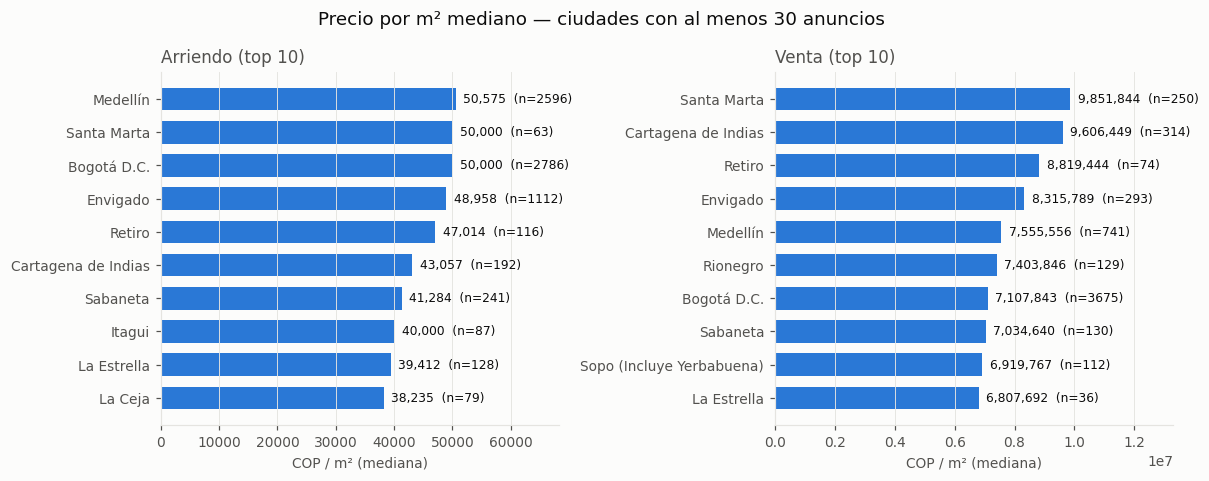

In [ ]:
N_MINIMO_CIUDAD = 30

for nombre, df in DATASETS.items():
    conteo = df["ciudad"].value_counts()
    print(f"{nombre.upper():9} | ciudades: {len(conteo):4}"
          f" | top5 = {conteo.head(5).sum() / len(df) * 100:.1f} % del dataset"
          f" | con < 10 anuncios: {(conteo < 10).sum():3} ({conteo[conteo < 10].sum()} filas)"
          f" | con >= {N_MINIMO_CIUDAD}: {(conteo >= N_MINIMO_CIUDAD).sum()}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4))
fig.suptitle(f"Precio por m² mediano — ciudades con al menos {N_MINIMO_CIUDAD} anuncios", fontsize=12)

for ax, (nombre, df) in zip(ejes, DATASETS.items()):
    # Se excluyen las casas con área sospechosa de lote: distorsionan el precio/m²
    base = df[df["area_m2"].between(20, 1000) & (df["precio_m2"] > 0)]
    agrupado = (base.groupby("ciudad")["precio_m2"]
                .agg(["count", "median"])
                .query(f"count >= {N_MINIMO_CIUDAD}")
                .nlargest(10, "median")
                .sort_values("median"))

    ax.barh(agrupado.index, agrupado["median"], color="#2a78d6", height=0.68)
    ax.set_title(f"{nombre.capitalize()} (top 10)", loc="left", color=TINTA_TENUE)
    ax.set_xlabel("COP / m² (mediana)")
    ax.grid(axis="y", visible=False)
    for y, (ciudad, fila) in enumerate(agrupado.iterrows()):
        ax.annotate(f"{fila['median']:,.0f}  (n={int(fila['count'])})",
                    xy=(fila["median"], y), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=8, color=TINTA)
    ax.set_xlim(0, agrupado["median"].max() * 1.35)

plt.tight_layout()
plt.show()

## 17. Decisiones que salen del estudio de distribución

Estas complementan las reglas R2–R12 de más abajo. Son las que dependen del análisis
estadístico, no del parseo.

### D0 — En el feed de arriendo, el precio de un dual es un precio de **venta**
El hallazgo de mayor impacto del estudio. Los 82 duales del feed de arriendo tienen todos
precio > $100.000.000/mes; su mediana es **333×** la de un arriendo normal. La
transformación separa `precio_arriendo` de `precio_venta` y, para un dual del feed de
arriendo, deja el canon en `NaN`. Sin esto, cualquier promedio de canon queda arruinado.

### D1 — Toda detección de outliers se hace en **escala logarítmica**
No es preferencia: en escala cruda la valla inferior de Tukey da negativa en las 6
combinaciones y no detecta ni un solo outlier bajo, mientras marca 7–9 % por arriba. En log
detecta ambas colas y marca 0,6–1,8 %.

### D2 — Umbrales **por operación y por tipo**, con piso de muestra
Vallas segmentadas cuando el segmento tiene **n ≥ 300**; si no, se usa el umbral global de
la operación. Evita que Apartaestudio en venta (n=175) genere un 7,4 % de falsos positivos
por inestabilidad del estimador.

### D3 — `precio_m2` es la variable de control, no `precio` ni `area_m2` por separado
Detecta 180 casos en arriendo y 232 en venta que las variables individuales no ven —
el 37 % y el 50 % del total de outliers respectivamente. Se calcula **después** de aplicar
D0, R5 y R6, no antes.

### D4 — Marcar `area_posible_lote` en casas, y excluirlas del precio/m²
Criterio: `tipo == 'Casa'` **y** `area_m2` fuera de la valla superior del segmento
apartamento. Son el 11,5 % de las casas en arriendo y el 8,2 % en venta (577 filas en
total). **No se descartan**: entran al dataset con la bandera puesta y quedan fuera sólo de
los indicadores por m².

### D5 — La columna `calidad` acumula motivos, no se sobreescribe
Una fila puede ser `precio_fuera_de_rango` **y** `area_posible_lote` a la vez. Guardar sólo
el último motivo pierde información. Se usa una lista de banderas booleanas, no un string
único.

### D6 — No publicar indicadores por ciudad con menos de 30 anuncios
Sólo 26 ciudades en arriendo y 36 en venta superan ese piso. Las demás siguen en el
dataset, pero no alimentan medianas por ciudad.

### D7 — Guardar el outlier marcado, nunca recortado (*winsorizar* tampoco)
El pipeline no reemplaza valores extremos por el percentil 99. Marcar preserva la
posibilidad de revisar; recortar la destruye y falsea la varianza.

### Orden de aplicación (importa)

```
1. Parseo dual (R4)        →  separa precio_arriendo / precio_venta   [D0]
2. Rangos por operación    →  R5, R6
3. Rangos de área          →  R7 + bandera area_posible_lote          [D4]
4. Cálculo de precio_m2    →  sólo sobre lo que sobrevivió 1–3        [D3]
5. IQR log segmentado      →  marca outliers                          [D1, D2]
```

Invertir los pasos 1 y 4 es el error clásico: se calcula `precio_m2` con un precio de venta
metido en el feed de arriendo, y el indicador queda inservible.

---

### Limitación honesta del análisis

Es **una sola extracción**, sin dimensión temporal. Todo lo anterior describe una foto del
mercado, no su evolución. Con un solo corte no se puede distinguir un precio atípico de un
precio que cambió, ni detectar anuncios que llevan meses publicados. Si el pipeline pasa a
correr periódicamente, `id_inmueble` ya permite ese seguimiento — es justamente para lo
que sirve la llave de R2.

---

# Reglas de negocio para Transform — versión 2

Actualizadas contra los datos corregidos. **Tres reglas se murieron porque el problema se
resolvió en la fuente**, y eso es exactamente lo que uno quiere: la mejor regla de limpieza
es la que no hace falta escribir.

## Reglas que ya no aplican

| Regla v1 | Estado | Motivo |
|---|---|---|
| **R1** — reparsear ubicación | ✅ resuelta en `extract.py` | 0 filas contaminadas |
| **R3** — taxonomía + `es_residencial` | ✅ resuelta en la fuente | el feed sólo trae vivienda |
| **R9** — nulos condicionados a residencial | ✅ sin objeto | ya no hay bodegas ni lotes |

## Reglas vigentes

### R2 — `id_inmueble` es la llave; deduplicar por ella
Último segmento de la ruta de `url`, sin querystring. **Ahora sí hay duplicados** (2 por
dataset) por el `src_url`, así que la deduplicación dejó de ser preventiva y es necesaria.
Se conserva la primera aparición: las copias son idénticas en precio, área y texto.

### R4 — Reconocer la operación **dual** `"Venta y Arriendo"`
82 filas en arriendo y 12 en venta. Hoy quedan con `tipo`, `sector` y `ciudad` en `NaN`
por un patrón de título que la regex no contempla. La transformación usa:

```
"([A-Za-zÁÉÍÓÚÑáéíóúñ ]+?)\s+en\s+((?:Venta|Arriendo)(?:\s+y\s+(?:Venta|Arriendo))?),\s*([^,]+),\s*([^,\n]+)"
```

y marca `operacion = 'ambas'`. **No se descartan**: son inmuebles reales y recuperables.

### R5 — Precio: normalizar a entero y acotar por operación
El punto es separador de miles. Umbrales por operación (unidades distintas):

- Arriendo: `[300.000 , 500.000.000]` COP/mes
- Venta: `[20.000.000 , 100.000.000.000]` COP

Los duales se validan contra el rango de **venta**, que es el precio que publican.
Fuera de rango → `precio = NaN` y `calidad = 'precio_fuera_de_rango'`.

### R6 — Anular precios de relleno
Dígito repetido 7+ veces o secuencia `123456`. Son 2 casos en arriendo y 3 en venta.
Pocos, pero son los que rompen cualquier promedio.

### R7 — Área: **un solo rango**, ya no por tipo
Al ser todo vivienda, se simplifica respecto de v1: válido en `[20 , 2.000]` m².
Deja fuera ~1,2 % de arriendo y ~2,0 % de venta (la casa de 20.000.000 m², el
apartaestudio de 3.000 m²). Fuera de rango → `area_m2 = NaN` y
`calidad = 'area_fuera_de_rango'`.

### R8 — `habitaciones`, `banos`, `parqueaderos` son variables **censuradas**
Topes de 5 / 5 / 4 con acumulación en el tope. Se guardan como `Int8` nullable más las
banderas `habitaciones_es_tope`, `banos_es_tope`, `parqueaderos_es_tope`.
**No imputar con la media**: hacia arriba el valor real es desconocido.

### R10 — Normalizar `ciudad` y `sector` como texto
Trim, colapsar espacios, unificar mayúsculas y tildes. La cardinalidad de `ciudad` ya es
sana (102 / 175), pero `sector` sigue teniendo variantes del mismo barrio por
mayúsculas (`CHICO` / `Chico` / `Chico Norte`).

### R11 — Un solo dataset de salida, con `operacion` como columna
Se concatenan ambos feeds. La llave del hecho es `(id_inmueble, operacion)`. Los 12
inmuebles presentes en los dos feeds son los duales de R4: se consolidan en **una** fila
con `operacion = 'ambas'`, no en dos.

### R12 — Marcar, no borrar
Ninguna regla elimina filas (salvo el dedup exacto de R2). Campo inválido → `NaN` + una
columna `calidad` con el motivo. El descarte lo decide la capa de análisis.

---

## Pendiente aguas arriba (`extract.py`)

No es transform, pero conviene anotarlo: `recolectar_anuncios_de_pagina()` deduplica por
URL completa y debería hacerlo por la ruta sin querystring. Elimina los duplicados de R2
en el origen y ahorra llamadas al navegador.